# Phase 4 - Modeling

We build and compare machine learning and deep learning models to **predict used car prices** using the prepared dataset from Phase 3. 

Because `price` is a continuous numeric target, we use a **regression** approach.

We:
- Train multiple models and compare results.
- Test a small set of hyperparameters and document improvements.
- Evaluate with **R², MAE, and RMSE** (reported in original price units).
- Visualize predictions, residuals, and feature importance.

80/20 train test split is used as our test design plan for consistent model comparison. The results of this modeling phase will be reviewed and finalized in the next phase.


## Load Dataset

We load the prepared and encoded dataset from Phase 3 to begin price modeling.  
We verify the dataset shape and available features to confirm that the data is complete and ready for the train test split.


In [ ]:
import pandas as pd

df = pd.read_csv("encoded_dataset.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()


Dataset shape: (2743730, 17)

Columns:
['price', 'year', 'combined_fuel_economy', 'mileage', 'fuel_type', 'transmission', 'body_type', 'engine_type', 'horsepower', 'torque', 'legroom', 'maximum_seating', 'size_of_vehicle', 'has_incidents', 'wheel_system', 'major_options_count', 'price_log']


,price,year,combined_fuel_economy,mileage,fuel_type,transmission,body_type,engine_type,horsepower,torque,legroom,maximum_seating,size_of_vehicle,has_incidents,wheel_system,major_options_count,price_log
0,83379.0,2019,73.5,323.000000,0,1,1,32,170.0,265.218839,80.166305,5,462.2,0,2,9.0,11.331152
1,24595.0,2021,52.0,1.000000,3,0,4,11,151.0,265.218839,79.700000,5,427.7,0,0,5.0,10.110298
2,21605.0,2020,34.0,6.000000,0,0,4,21,158.0,138.000000,79.700000,5,427.9,0,0,1.0,9.980680
3,28330.0,2020,28.0,31146.901467,0,1,1,21,187.0,186.000000,80.600000,5,449.6,0,0,4.0,10.251677
4,51975.0,2020,23.0,1.000000,0,1,4,1,300.0,295.000000,79.600000,5,450.8,0,2,8.0,10.858518


## Select Features and Train–Test Split

We define `price` as the target and use the remaining columns as features for regression.  
To avoid duplicate targets, we drop `price_log` and keep the modeling target in raw price units.

In [2]:
from sklearn.model_selection import train_test_split

df = df.drop(columns=["price_log"])

target = "price"
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nFeatures used:", len(features))


Train shape: (2194984, 15)
Test shape: (548746, 15)

Features used: 15


## Scale Numerical Features

To prepare the data for modeling, the numerical features are standardized using `StandardScaler`.  
This ensures that models sensitive to feature magnitude (such as Linear Regression and MLP) train effectively.


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:2]


array([[-0.43347217, -0.93892414,  1.02930395, -0.26652733,  0.2832443 ,
         1.82775335,  0.70060434,  1.22586719,  1.09071371, -0.11152251,
         0.49181392,  1.68496903, -0.25580504, -0.02487053, -0.39117271],
       [-0.43347217, -0.87339255,  0.24943588,  1.01774768,  0.2832443 ,
         1.82775335,  0.20595679,  0.67478897,  1.34011344, -1.3764663 ,
         0.49181392,  1.66862196, -0.25580504, -0.02487053, -0.68123684]])

## Baseline Model: Linear Regression

We start with Linear Regression as a simple baseline on the scaled feature set.  
This gives a clear reference point for how much improvement we gain from non-linear and tuned models.


In [4]:
# train

from sklearn.linear_model import LinearRegression
import time

lr = LinearRegression()

_start = time.perf_counter()
lr.fit(X_train_scaled, y_train)
lr_time = time.perf_counter() - _start


In [5]:
# predict

lr_preds = lr.predict(X_test_scaled)
lr_preds[:5]


array([42559.51525591, 20288.78422867, 53882.00619536, 25106.72666847,
       33765.66111748])

In [6]:
# metrics

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print("Linear Regression Metrics")
print("R²:", lr_r2)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)


Linear Regression Metrics
R²: 0.5352066025363295
MAE: 7007.768463873327
RMSE: 12528.341237895682


What we see:

- R² = 0.535, so Linear Regression explains about 54% of the variation in price. This suggests our selected features already capture a meaningful part of the price signal.
- MAE = 7,008, meaning the model is typically off by around $7k.
- RMSE = 12,528, which indicates some larger errors, likely from expensive or less common listings that a linear model cannot fit well.

Overall, this works well as a baseline. Any advanced model should improve both the error metrics and the fit by capturing non-linear relationships in the data.


#### Two visualizations are generated to evaluate the Linear Regression baseline model:
   - Shows how close the predictions are to the true prices.
   - Shows how errors are spread and highlights potential non-linear patterns.


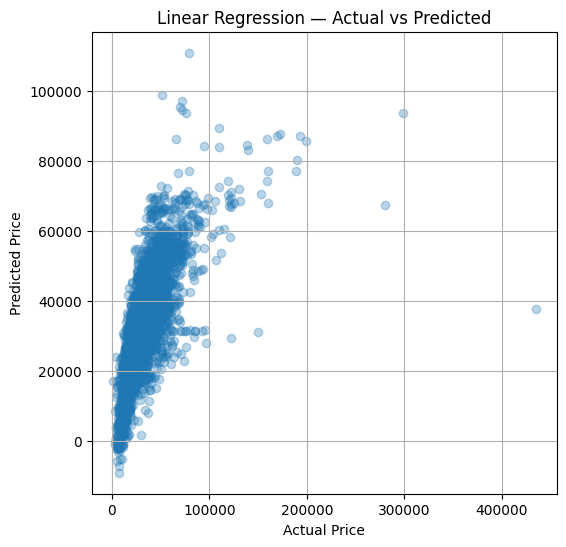

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test.iloc[:5000], lr_preds[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression — Actual vs Predicted")
plt.grid(True)
plt.show()


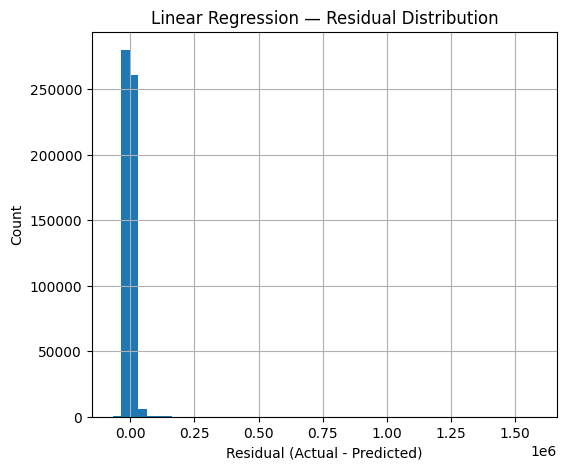

In [ ]:
residuals = y_test - lr_preds

plt.figure(figsize=(6, 5))
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Linear Regression — Residual Distribution")
plt.grid(True)
plt.show()


What we see:
- The trend is right, but the spread grows for expensive cars.
- Residuals have a long tail, meaning a small group of cars creates large errors.

This is a good baseline, but we likely need non-linear models for better high-price accuracy.


## Random Forest Regressor

A Random Forest model is trained to capture the complex interactions in our used car data. 
We expect it to significantly outperform the linear baseline by leveraging feature combinations (e.g. age and mileage together) and handling outlier prices better than a linear model


In [9]:
# train

from sklearn.ensemble import RandomForestRegressor
import time

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

_start = time.perf_counter()
rf.fit(X_train, y_train)
rf_time = time.perf_counter() - _start


In [10]:
# predict

rf_preds = rf.predict(X_test)
rf_preds[:5]


array([52628.22222222, 16912.66      , 41258.35438095, 22189.93      ,
       23342.52      ])

In [11]:
# metrics

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Random Forest Metrics")
print("R²:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)


Random Forest Metrics
R²: 0.8706979278034995
MAE: 2478.656502493694
RMSE: 6607.943808939672


With R² jumping to about 0.87 (from 0.53), Random Forest dramatically improves fit. MAE drops to about USD 2.5k ( about 8% of the about USD 32k average price), and RMSE to about USD 6.6k, indicating far fewer large errors. This confirms that a tree based model leveraged key factors (like horsepower, year, torque, mileage) to capture price trends, making Random Forest a top candidate for our final model set

#### Random Forest Feature Importance and Visualizations

To understand how the model prioritizes different attributes, feature importances are extracted from the Random Forest.  
Visualizations are also generated to compare actual vs predicted values and to examine residual patterns.


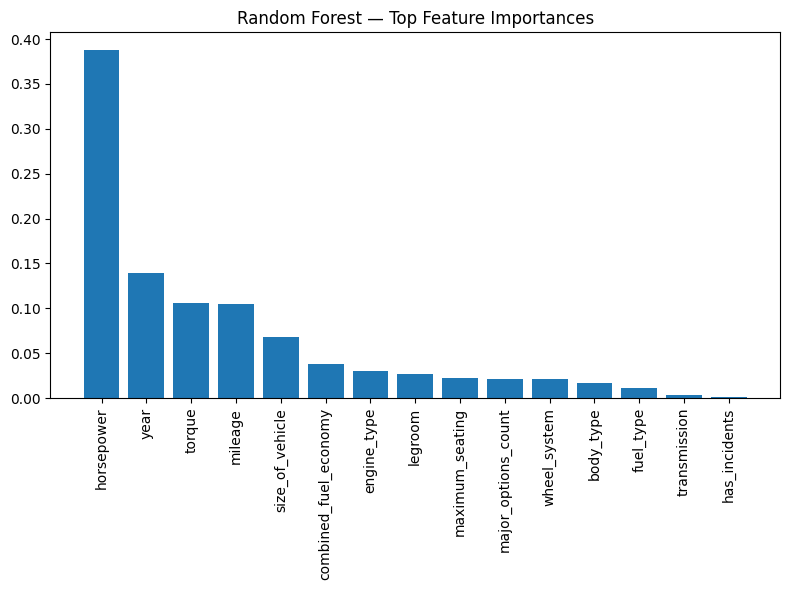

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(8, 6))
plt.bar(range(top_n), importances[indices][:top_n])
plt.xticks(range(top_n), [features[i] for i in indices][:top_n], rotation=90)
plt.title("Random Forest — Top Feature Importances")
plt.tight_layout()
plt.show()


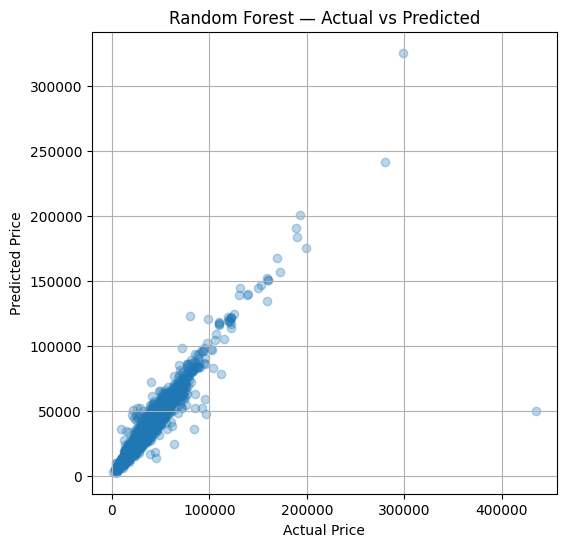

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test.iloc[:5000], rf_preds[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest — Actual vs Predicted")
plt.grid(True)
plt.show()


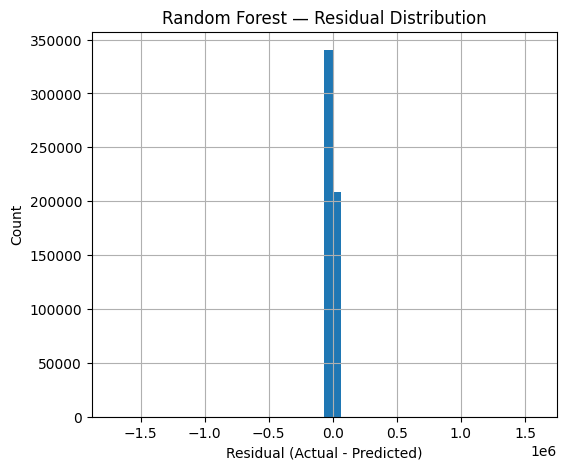

In [ ]:
rf_residuals = y_test - rf_preds

plt.figure(figsize=(6, 5))
plt.hist(rf_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Random Forest — Residual Distribution")
plt.grid(True)
plt.show()


What we see:
- Feature importance highlights horsepower, year, torque, and mileage as the strongest price drivers, which matches our earlier expectations for used cars.
- The actual vs predicted points are much closer to the diagonal than Linear Regression.
- Residuals are tighter around zero, showing fewer large errors overall.

Random Forest looks like a strong non-linear baseline and a good candidate for the final top models.


## Gradient Boosting Regressor

A Gradient Boosting model is trained next, with the idea that iterative boosting can focus on cases where the Random Forest still erred (for example, very high-priced cars). This approach sequentially corrects previous errors, so we expect it to further improve predictive performance if tuned well.

In [15]:
# train

from sklearn.ensemble import GradientBoostingRegressor
import time

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

_start = time.perf_counter()
gbr.fit(X_train, y_train)
gbr_time = time.perf_counter() - _start


In [16]:
# predict

gbr_preds = gbr.predict(X_test)
gbr_preds[:5]


array([50475.96270828, 17495.59789721, 43173.76668621, 23706.55043337,
       30605.0406269 ])

In [17]:
# metrics

gbr_r2 = r2_score(y_test, gbr_preds)
gbr_mae = mean_absolute_error(y_test, gbr_preds)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_preds))

print("Gradient Boosting Metrics")
print("R²:", gbr_r2)
print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)


Gradient Boosting Metrics
R²: 0.8336127430948712
MAE: 3811.9115298035026
RMSE: 7495.897335303998


Gradient Boosting achieved R² ≈ 0.834, which is strong but lower than Random Forest’s 0.871. Its errors (MAE $3.8k) are larger on average, indicating that in this initial setup the Random Forest’s deeper trees captured patterns better. This suggests our boosting model might need further tuning (e.g. more trees or depth) to catch up to the Random Forest in accuracy.

#### Gradient Boosting Feature Importance and Visualizations

The feature importances from the Gradient Boosting model are examined.  
Additional plots are generated to evaluate prediction behavior and residual patterns.

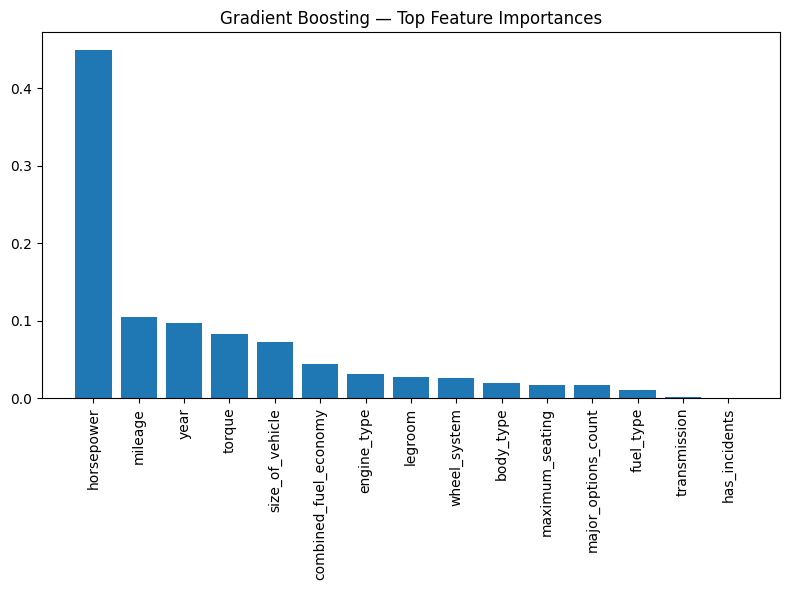

In [ ]:
importances_gbr = gbr.feature_importances_
indices_gbr = np.argsort(importances_gbr)[::-1]
top_n = 15

plt.figure(figsize=(8, 6))
plt.bar(range(top_n), importances_gbr[indices_gbr][:top_n])
plt.xticks(range(top_n), [features[i] for i in indices_gbr][:top_n], rotation=90)
plt.title("Gradient Boosting — Top Feature Importances")
plt.tight_layout()
plt.show()


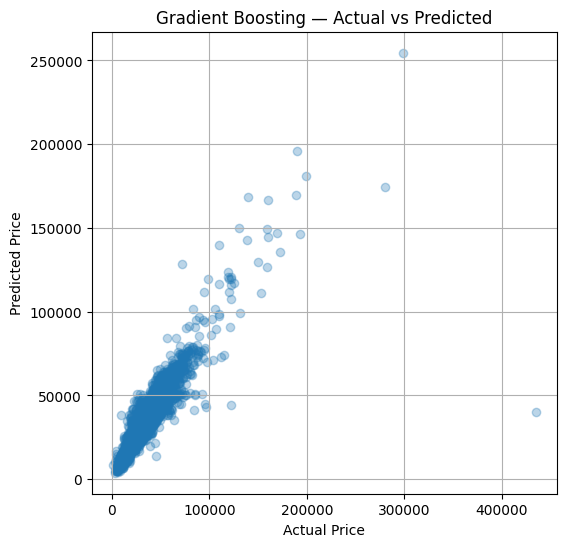

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test.iloc[:5000], gbr_preds[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient Boosting — Actual vs Predicted")
plt.grid(True)
plt.show()


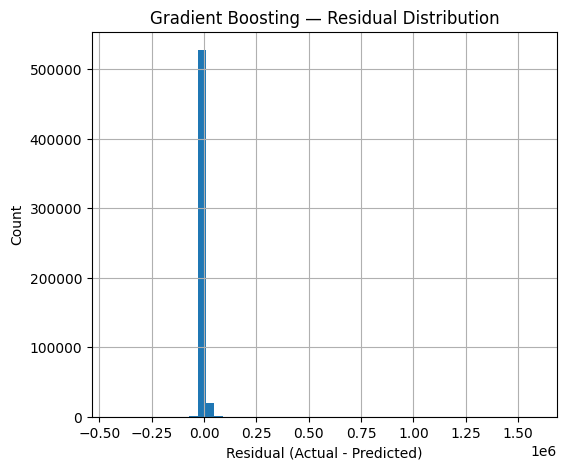

In [ ]:
gbr_residuals = y_test - gbr_preds

plt.figure(figsize=(6, 5))
plt.hist(gbr_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Gradient Boosting — Residual Distribution")
plt.grid(True)
plt.show()


Gradient Boosting achieved R² ≈ 0.834, which is strong but lower than Random Forest’s 0.871. Its errors (MAE $3.8k) are larger on average, indicating that in this initial setup the Random Forest’s deeper trees captured patterns better. 

This suggests our boosting model might need further tuning (e.g. more trees or depth) to catch up to the Random Forest in accuracy.

## XGBoost Regressor

An XGBoost model is trained as an advanced boosting approach. 

XGBoost is known for efficiency on large tabular data with our 2.7 million records, we expect it to handle the dataset quickly and possibly match or exceed Random Forest’s accuracy by using a optimized gradient-boosted tree algorithm

In [21]:
# train

from xgboost import XGBRegressor
import time

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

_start = time.perf_counter()
xgb.fit(X_train, y_train)
xgb_time = time.perf_counter() - _start


In [22]:
# predict

xgb_preds = xgb.predict(X_test)
xgb_preds[:5]


array([53585.44 , 17265.105, 42620.35 , 23529.254, 26184.352],
      dtype=float32)

In [23]:
# metrics

xgb_r2 = r2_score(y_test, xgb_preds)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print("XGBoost Metrics")
print("R²:", xgb_r2)
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)


XGBoost Metrics
R²: 0.8724387473510962
MAE: 3101.7863145066376
RMSE: 6563.311043213569


XGBoost’s performance closely matches Random Forest. R² 0.872 is on par with RF, and RMSE is similarly low ($6.56k). Its MAE ($3.1k) is slightly higher than RF’s ($2.5k), indicating a bit larger average error in some price ranges. 

Overall, XGBoost captured the non-linear patterns almost as well as RF, confirming it as a strong contender in our top model list.

#### XGBoost Feature Importance and Visualizations

Feature importances and evaluation plots are generated for the XGBoost model.  
These help interpret how each variable contributes to price prediction.


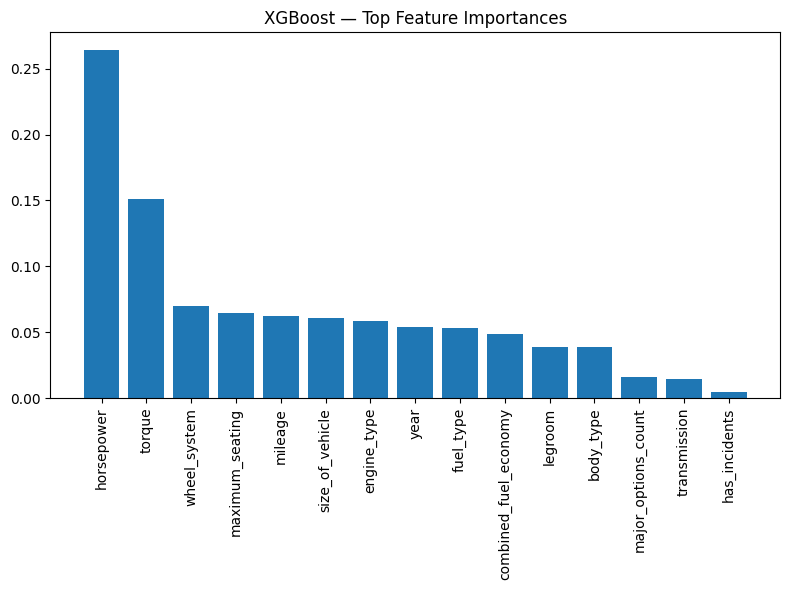

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

xgb_importances = xgb.feature_importances_
indices_xgb = np.argsort(xgb_importances)[::-1]
top_n = 15

plt.figure(figsize=(8, 6))
plt.bar(range(top_n), xgb_importances[indices_xgb][:top_n])
plt.xticks(range(top_n), [features[i] for i in indices_xgb][:top_n], rotation=90)
plt.title("XGBoost — Top Feature Importances")
plt.tight_layout()
plt.show()


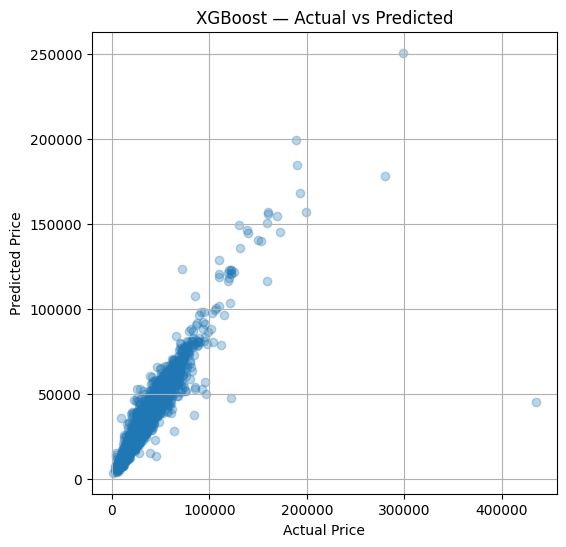

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test.iloc[:5000], xgb_preds[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost — Actual vs Predicted")
plt.grid(True)
plt.show()


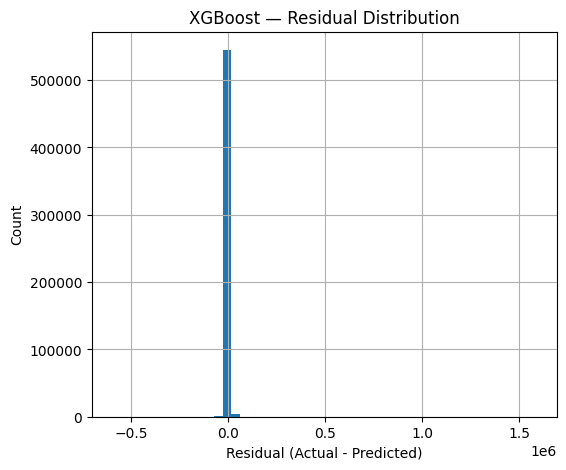

In [ ]:
xgb_residuals = y_test - xgb_preds

plt.figure(figsize=(6, 5))
plt.hist(xgb_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("XGBoost — Residual Distribution")
plt.grid(True)
plt.show()


- Horsepower and torque lead the importance ranking, with mileage, year, and wheel system also contributing.
- The actual vs predicted plot looks tightly aligned, similar to Random Forest.
- Residuals are centered near zero with fewer extreme errors.

XGBoost confirms strong non-linear pricing signals and is a good candidate for the final top models.


## CatBoost Regressor

We train a CatBoost model as another powerful boosting method. CatBoost can handle categorical features natively and often performs well out-of-the-box. 

By including CatBoost, we check if its handling of our features (many of which started as categories) yields competitive accuracy without extensive tuning

In [27]:
from catboost import CatBoostRegressor

# train
cb = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

_start = time.perf_counter()
cb.fit(X_train, y_train)
cb_time = time.perf_counter() - _start


In [28]:
# predict
cb_preds = cb.predict(X_test)
cb_preds[:5]


array([52452.81411674, 18236.49998697, 42110.50058093, 23470.99578684,
       30814.22292183])

In [29]:
# metrics
cb_r2 = r2_score(y_test, cb_preds)
cb_mae = mean_absolute_error(y_test, cb_preds)
cb_rmse = np.sqrt(mean_squared_error(y_test, cb_preds))

print("CatBoost Metrics")
print("R²:", cb_r2)
print("MAE:", cb_mae)
print("RMSE:", cb_rmse)

CatBoost Metrics
R²: 0.8485451488163144
MAE: 3603.896461799539
RMSE: 7151.632562105828


CatBoost delivered R² ≈ 0.849, indicating robust performance but slightly trailing Random Forest and XGBoost. Its MAE ($3.60k) and RMSE ($7.15k) are higher than the best models, suggesting that with default parameters it didn’t capture the price variability as strongly. 

In this run, CatBoost clearly outperforms the linear baseline but falls just short of the top tree models (likely needing deeper trees or more iterations to bridge the gap).

#### CatBoost Visualizations

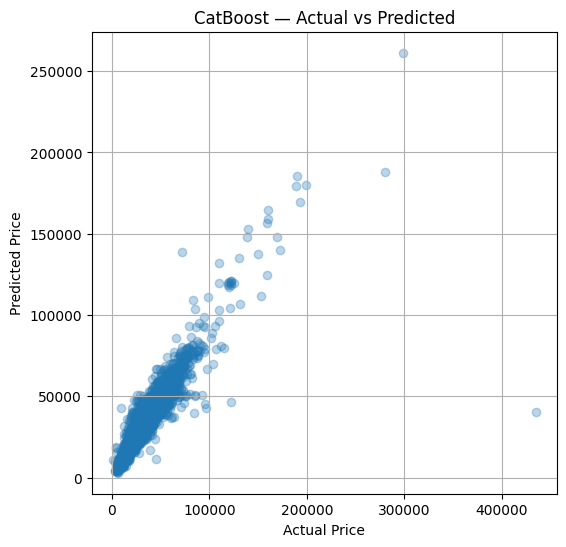

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test.iloc[:5000], cb_preds[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("CatBoost — Actual vs Predicted")
plt.grid(True)
plt.show()

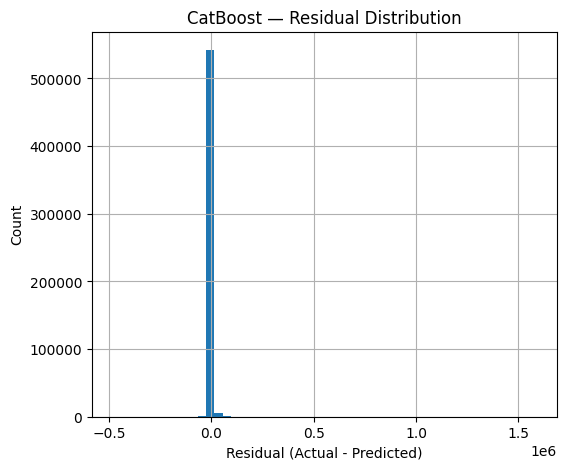

In [ ]:
cb_residuals = y_test - cb_preds

plt.figure(figsize=(6, 5))
plt.hist(cb_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("CatBoost — Residual Distribution")
plt.grid(True)
plt.show()


- The actual vs predicted plot follows the diagonal well, but with a bit more spread compared to the strongest models.
- Residuals are mostly centered near zero, with some larger errors still present.

CatBoost is stable and clearly better than the linear baseline, but it may not beat RF/XGBoost in this setup.


## LightGBM Regressor

A LightGBM model is trained as another gradient boosting framework. LightGBM is optimized for speed and scalability, so with our large dataset we expect fast training and accuracy comparable to XGBoost. 

This model will test if LightGBM’s efficiency and tree optimizations can maintain high prediction quality on our data.

In [32]:
from lightgbm import LGBMRegressor

# train
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

_start = time.perf_counter()
lgbm.fit(X_train, y_train)
lgbm_time = time.perf_counter() - _start


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.292028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1456
[LightGBM] [Info] Number of data points in the train set: 2194984, number of used features: 15
[LightGBM] [Info] Start training from score 31740.151212


In [33]:
# predict
lgbm_preds = lgbm.predict(X_test)
lgbm_preds[:5]


array([51535.59621926, 17564.07764922, 42273.24903181, 23392.25574959,
       26579.87465017])

In [34]:
# metrics
lgbm_r2 = r2_score(y_test, lgbm_preds)
lgbm_mae = mean_absolute_error(y_test, lgbm_preds)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_preds))

print("LightGBM Metrics")
print("R²:", lgbm_r2)
print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

LightGBM Metrics
R²: 0.8639552421014554
MAE: 3383.00041608847
RMSE: 6778.045890221481


LightGBM shows R² ≈ 0.864, very close to the top models, indicating it captured most price variance. MAE is $3.38k and RMSE $6.78k, only slightly behind Random Forest’s error levels. 

Given its accuracy and faster training on millions of records, LightGBM proves to be a strong candidate for our final model selection, nearly matching the best models while being computationally efficient.

#### LightGBM Visualizations



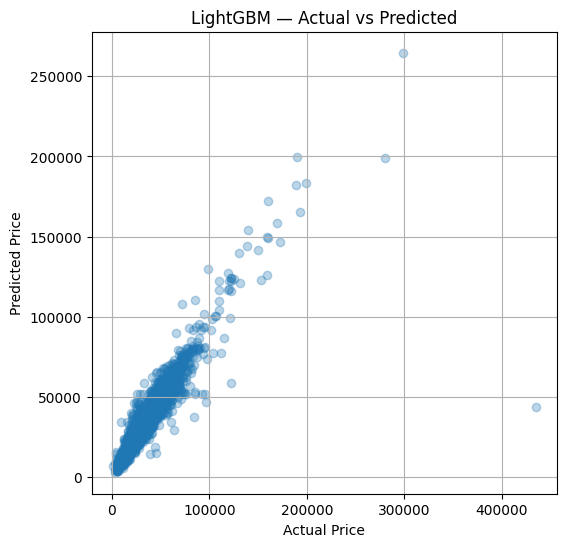

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test.iloc[:5000], lgbm_preds[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("LightGBM — Actual vs Predicted")
plt.grid(True)
plt.show()

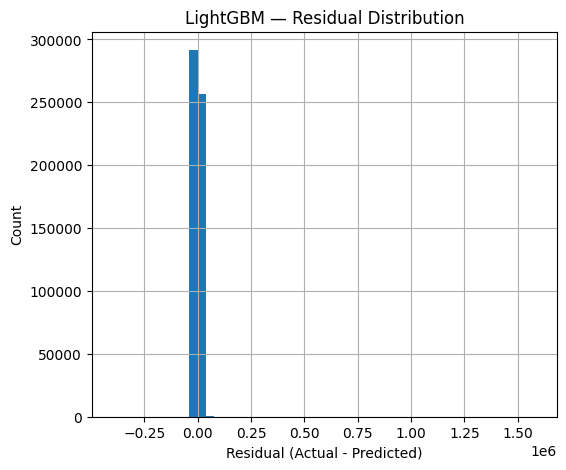

In [ ]:
lgbm_residuals = y_test - lgbm_preds

plt.figure(figsize=(6, 5))
plt.hist(lgbm_residuals, bins=50)
plt.xlabel("Residual (Actual — Predicted)")
plt.ylabel("Count")
plt.title("LightGBM — Residual Distribution")
plt.grid(True)
plt.show()

What we see:
- The actual vs predicted plot tracks the diagonal well, with some spread at higher prices.
- Residuals are mostly centered near zero, suggesting stable overall performance.

LightGBM looks competitive with the best tree models and is worth keeping in the final comparison.


## MLP Regressor (Deep Learning)

A Multi-Layer Perceptron neural network is trained as our deep learning model for price prediction. Neural networks can capture very complex non-linear patterns; however, training on millions of samples is computationally intensive, so we use a limited iteration run. 

This gives a quick sense of whether a neural net can glean additional structure from the data beyond what tree models achieved



In [37]:
# train

from sklearn.neural_network import MLPRegressor
import time

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=5,
    random_state=42
)

_start = time.perf_counter()
mlp.fit(X_train_scaled, y_train)
mlp_time = time.perf_counter() - _start


In [38]:
# predict

mlp_preds = mlp.predict(X_test_scaled)
mlp_preds[:5]


array([47747.01205921, 18150.84091896, 45320.65030029, 21796.19593395,
       26700.56591393])

In [39]:
# metrics

mlp_r2 = r2_score(y_test, mlp_preds)
mlp_mae = mean_absolute_error(y_test, mlp_preds)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_preds))

print("MLP Regressor Metrics")
print("R²:", mlp_r2)
print("MAE:", mlp_mae)
print("RMSE:", mlp_rmse)


MLP Regressor Metrics
R²: 0.7762097179408818
MAE: 4299.223774294753
RMSE: 8693.290862971808


The MLP achieved R² ≈ 0.776, learning useful patterns but significantly trailing the tree-based models in accuracy. Its MAE ($4.3k) and RMSE ($8.69k) are much higher than those of Random Forest or XGBoost, indicating larger typical errors. 

This suggests that with the short training (only a few epochs) the neural network underfit the data, tree ensembles still capture our structured features more effectively given the current setup

#### MLP Regressor Visualizations

The prediction results from the neural network model are visualized through:
- Actual vs Predicted scatter plot  
- Residual distribution plot

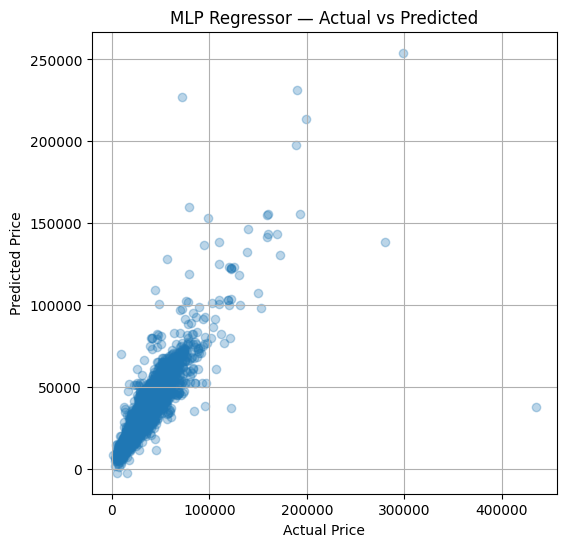

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test[:5000], mlp_preds[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("MLP Regressor — Actual vs Predicted")
plt.grid(True)
plt.show()


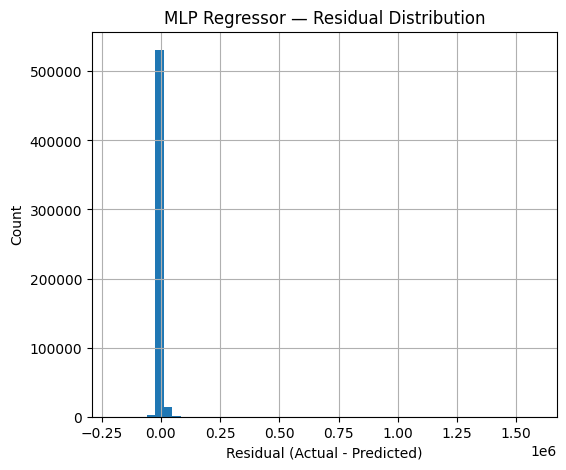

In [ ]:
mlp_residuals = y_test - mlp_preds

plt.figure(figsize=(6, 5))
plt.hist(mlp_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("MLP Regressor — Residual Distribution")
plt.grid(True)
plt.show()


- The actual vs predicted plot shows a clear relationship, but with more spread than the best tree models.
- Residuals are mostly centered near zero, though larger errors still appear for high-price cars.

MLP provides a useful deep learning baseline, but tree-based models still look more reliable for this dataset.

## Keras Deep Learning Model

We also build a deeper neural network using TensorFlow/Keras to see if a custom architecture can improve on the scikit-learn MLP. 

This sequential model is trained on the standardized features; by using more layers (and techniques like dropout), we aim to learn complex feature interactions, though we anticipate it will require careful tuning to rival the accuracy of our best tree models


In [42]:
# Build Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

tf.random.set_seed(42)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# train

import time

_start = time.perf_counter()
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=3,
    batch_size=256,
    verbose=1
)
keras_time = time.perf_counter() - _start


Epoch 1/3
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 205446640.0000
Epoch 2/3
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 143945488.0000
Epoch 3/3
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 132585568.0000


In [44]:
# predict

keras_preds = model.predict(X_test_scaled).ravel()
keras_preds[:5]


17149/17149 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step


array([44532.184, 17616.38 , 44815.625, 23607.135, 31689.584],
      dtype=float32)

In [45]:
# metrics

keras_r2 = r2_score(y_test, keras_preds)
keras_mae = mean_absolute_error(y_test, keras_preds)
keras_rmse = np.sqrt(mean_squared_error(y_test, keras_preds))

print("Keras Deep Learning Model Metrics")
print("R²:", keras_r2)
print("MAE:", keras_mae)
print("RMSE:", keras_rmse)


Keras Deep Learning Model Metrics
R²: 0.7401403436606393
MAE: 4569.043492113285
RMSE: 9367.701178900648


R² = 0.740 shows the Keras model learned some patterns but did worse than the MLP and tree models, likely due to limited training or tuning. MAE = $4,569 and RMSE = $9,368 mean higher errors, especially on expensive cars, so it's not as reliable as the tree-based models.

#### Keras Visualizations

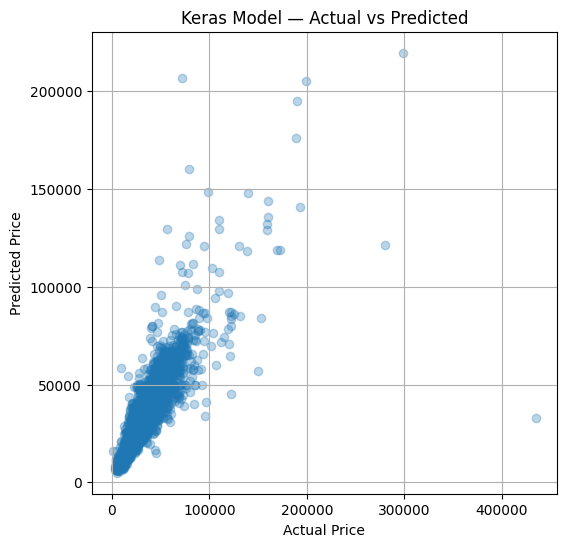

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test.iloc[:5000], keras_preds[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Keras Model — Actual vs Predicted")
plt.grid(True)
plt.show()


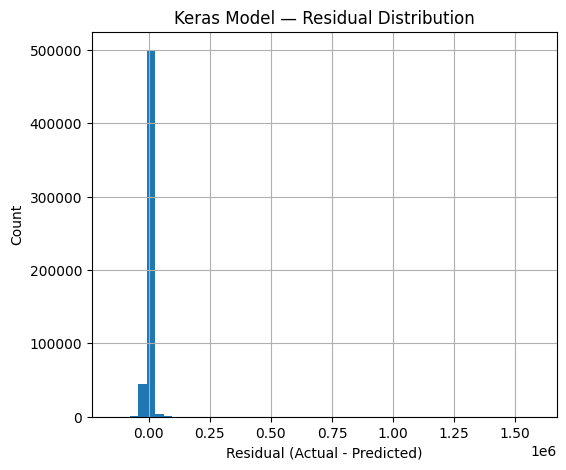

In [ ]:
keras_residuals = y_test - keras_preds

plt.figure(figsize=(6, 5))
plt.hist(keras_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Keras Model — Residual Distribution")
plt.grid(True)
plt.show()


- The actual vs predicted plot follows the general trend but shows wider spread than the other models.
- Residuals are centered near zero, but larger errors still appear for expensive cars.

This supports the metric results: the Keras model is useful for comparison, but it is not among the strongest choices for this dataset.

## Hyperparameter Tuning (400,000-row Sample)

We tune models on a 400,000-row sample from the training set to keep computation practical.  
This lets us check whether small hyperparameter changes improve performance before retraining on the full training data.

We also tune Ridge as a fast, fairer linear baseline to compare against non-linear methods.  
We do not tune the Keras model because its baseline performance was clearly below the strongest models.

We use small grids for Ridge, Random Forest, XGBoost, Gradient Boosting, CatBoost, LightGBM, and MLP, with GridSearchCV (2–3 folds).


In [48]:
import pandas as pd

train_df = df.loc[X_train.index].copy()

df_sample = train_df.sample(400000, random_state=42)  

X_sample = df_sample[features]
y_sample = df_sample[target]


In [49]:
scaler_sample = StandardScaler()
X_sample_scaled = scaler_sample.fit_transform(X_sample)

### Ridge Regression Tuning (Tuned Linear Model)

Ridge adds L2 regularization to Linear Regression and can improve generalization.

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_base = Ridge()

ridge_search = GridSearchCV(
    ridge_base,
    ridge_grid,
    cv=3,
    scoring="r2",
    verbose=1
)

ridge_search.fit(X_sample_scaled, y_sample)

print("Ridge Best Params:", ridge_search.best_params_)
print("Ridge Best R2:", ridge_search.best_score_)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Ridge Best Params: {'alpha': 100}
Ridge Best R2: 0.49273585062021547


### Random Forest Tuning
A small grid was used to evaluate tree depth and number of estimators.  
This typically improves performance while keeping the model efficient.


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None]
}

rf_base = RandomForestRegressor(n_jobs=-1, random_state=42)

rf_search = GridSearchCV(
    rf_base, 
    rf_grid,
    cv=3,
    scoring="r2",
    verbose=1
)

rf_search.fit(X_sample, y_sample)

print("RF Best Params:", rf_search.best_params_)
print("RF Best R2:", rf_search.best_score_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
RF Best Params: {'max_depth': 20, 'n_estimators': 100}
RF Best R2: 0.7592992887973636


### XGBoost Tuning
A lightweight parameter grid was used to keep training efficient.  
XGBoost is computationally heavier, so cv=2 was used.


In [52]:
from xgboost import XGBRegressor

xgb_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 8],
    "learning_rate": [0.05, 0.1]
}

xgb_base = XGBRegressor(
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

xgb_search = GridSearchCV(
    xgb_base,
    xgb_grid,
    cv=2,
    scoring="r2",
    verbose=1
)

xgb_search.fit(X_sample, y_sample)

print("XGB Best Params:", xgb_search.best_params_)
print("XGB Best R2:", xgb_search.best_score_)


Fitting 2 folds for each of 8 candidates, totalling 16 fits
XGB Best Params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
XGB Best R2: 0.8181790596297498


### Gradient Boosting Tuning
Gradient Boosting benefits from tuning learning rate and depth.  
A small grid is sufficient due to long training time.


In [53]:
from sklearn.ensemble import GradientBoostingRegressor

gb_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

gb_base = GradientBoostingRegressor(random_state=42)

gb_search = GridSearchCV(
    gb_base,
    gb_grid,
    cv=2,
    scoring="r2",
    verbose=1
)

gb_search.fit(X_sample, y_sample)

print("GB Best Params:", gb_search.best_params_)
print("GB Best R2:", gb_search.best_score_)


Fitting 2 folds for each of 8 candidates, totalling 16 fits
GB Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
GB Best R2: 0.8064421111088027


### CatBoost Tuning
A small grid is used to test key CatBoost parameters efficiently.

In [54]:
from catboost import CatBoostRegressor

cb_grid = {
    "iterations": [300, 600],
    "learning_rate": [0.05, 0.1],
    "depth": [6, 8]
}

cb_base = CatBoostRegressor(
    random_state=42,
    verbose=0
)

cb_search = GridSearchCV(
    cb_base,
    cb_grid,
    cv=2,
    scoring="r2",
    verbose=1
)

cb_search.fit(X_sample, y_sample)

print("CatBoost Best Params:", cb_search.best_params_)
print("CatBoost Best R2:", cb_search.best_score_)


Fitting 2 folds for each of 8 candidates, totalling 16 fits
CatBoost Best Params: {'depth': 8, 'iterations': 600, 'learning_rate': 0.1}
CatBoost Best R2: 0.8220164083914067


### LightGBM Tuning

A small grid is used to tune estimators, learning rate, and leaf complexity.

In [55]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

lgbm_grid = {
    "n_estimators": [200, 500],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 50, 70]
}

lgbm_base = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbose=-1,           
    force_row_wise=True   
)

lgbm_search = GridSearchCV(
    lgbm_base,
    lgbm_grid,
    cv=3,
    scoring="r2",
    verbose=1             
)

lgbm_search.fit(X_sample, y_sample)

print("LightGBM Best Params:", lgbm_search.best_params_)
print("LightGBM Best R2:", lgbm_search.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
LightGBM Best Params: {'learning_rate': 0.1, 'n_estimators': 500, 'num_leaves': 50}
LightGBM Best R2: 0.8200679786784173


### MLP Regressor Tuning
Neural networks are computationally expensive, so a very small grid was used.  
The goal is to show improvement, not full deep-learning optimization.


In [56]:
from sklearn.neural_network import MLPRegressor

mlp_grid = {
    "hidden_layer_sizes": [(64,32), (128,64,32)],
    "learning_rate_init": [0.001, 0.0005]
}

mlp_base = MLPRegressor(
    max_iter=5,
    random_state=42
)

mlp_search = GridSearchCV(
    mlp_base,
    mlp_grid,
    cv=2,
    scoring="r2",
    verbose=1
)

mlp_search.fit(X_sample_scaled, y_sample)

print("MLP Best Params:", mlp_search.best_params_)
print("MLP Best R2:", mlp_search.best_score_)


Fitting 2 folds for each of 4 candidates, totalling 8 fits
MLP Best Params: {'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.001}
MLP Best R2: 0.5972189020832157


## Retrain Tuned Models on Full Dataset

### Retrain Tuned Ridge on Full Dataset

We retrain Ridge on the full training set using the best alpha value from tuning.  
The goal is to get final test metrics for a stronger linear baseline and compare it fairly against the non-linear models.

In [57]:
from sklearn.linear_model import Ridge
import time

ridge_tuned = Ridge(**ridge_search.best_params_)

_start = time.perf_counter()
ridge_tuned.fit(X_train_scaled, y_train)
ridge_tuned_time = time.perf_counter() - _start

ridge_tuned_preds = ridge_tuned.predict(X_test_scaled)

ridge_tuned_r2 = r2_score(y_test, ridge_tuned_preds)
ridge_tuned_mae = mean_absolute_error(y_test, ridge_tuned_preds)
ridge_tuned_rmse = np.sqrt(mean_squared_error(y_test, ridge_tuned_preds))

print("Tuned Ridge Metrics")
print("R²:", ridge_tuned_r2)
print("MAE:", ridge_tuned_mae)
print("RMSE:", ridge_tuned_rmse)


Tuned Ridge Metrics
R²: 0.5352075543611441
MAE: 7007.608647435919
RMSE: 12528.328409838907


- Ridge gives almost the same results as Linear Regression
- This means regularization does not meaningfully improve a linear approach for this dataset.

So Ridge works as a cleaner linear baseline, but the main gains should come from non-linear models.

### Retrain Tuned Random Forest on Full Dataset

We retrain Random Forest on the full training set using the best tuning results (`n_estimators=100`, `max_depth=20`).  
We then evaluate on the unchanged test set to confirm whether tuning improves the untuned baseline.


In [58]:
# train

import time

rf_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

_start = time.perf_counter()
rf_tuned.fit(X_train, y_train)
rf_tuned_time = time.perf_counter() - _start


In [59]:
# Predict + Metrics

rf_tuned_preds = rf_tuned.predict(X_test)

rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))

print("Tuned Random Forest Metrics")
print("R²:", rf_tuned_r2)
print("MAE:", rf_tuned_mae)
print("RMSE:", rf_tuned_rmse)


Tuned Random Forest Metrics
R²: 0.8761055384032114
MAE: 2462.818365501507
RMSE: 6468.290927749595


Tuning slightly improved Random Forest because limiting depth and increasing trees helps reduce overfitting and stabilizes predictions on this large, noisy price dataset.

### Retrain Tuned XGBoost on Full Dataset

The XGBoost model is retrained on the full training set using the best hyperparameters found during tuning  
(`learning_rate=0.05`, `max_depth=8`, `n_estimators=100`).  
The tuned model is then evaluated on the full test set.


In [60]:
# train

import time

xgb_tuned = XGBRegressor(
    learning_rate=0.05,
    max_depth=8,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

_start = time.perf_counter()
xgb_tuned.fit(X_train, y_train)
xgb_tuned_time = time.perf_counter() - _start


In [61]:
# Predict + Metrics

xgb_tuned_preds = xgb_tuned.predict(X_test)

xgb_tuned_r2 = r2_score(y_test, xgb_tuned_preds)
xgb_tuned_mae = mean_absolute_error(y_test, xgb_tuned_preds)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_preds))

print("Tuned XGBoost Metrics")
print("R²:", xgb_tuned_r2)
print("MAE:", xgb_tuned_mae)
print("RMSE:", xgb_tuned_rmse)


Tuned XGBoost Metrics
R²: 0.8597876648280744
MAE: 3335.376782675467
RMSE: 6881.081631296443


Tuning made it worse on the test set, likely because the small tuning sample/grid didn’t match the full data patterns and the default settings were already a strong fit.

### Retrain Tuned Gradient Boosting on Full Dataset

The Gradient Boosting model is retrained on the full data using the best hyperparameters  
(`learning_rate=0.1`, `max_depth=3`, `n_estimators=200`) from the tuning experiment.
The final model is then evaluated on the full test set.


In [62]:
# train

from sklearn.ensemble import GradientBoostingRegressor
import time

gb_tuned = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    random_state=42
)

_start = time.perf_counter()
gb_tuned.fit(X_train, y_train)
gb_tuned_time = time.perf_counter() - _start


In [63]:
# Predict + Metrics

gb_tuned_preds = gb_tuned.predict(X_test)

gb_tuned_r2 = r2_score(y_test, gb_tuned_preds)
gb_tuned_mae = mean_absolute_error(y_test, gb_tuned_preds)
gb_tuned_rmse = np.sqrt(mean_squared_error(y_test, gb_tuned_preds))

print("Tuned Gradient Boosting Metrics")
print("R²:", gb_tuned_r2)
print("MAE:", gb_tuned_mae)
print("RMSE:", gb_tuned_rmse)


Tuned Gradient Boosting Metrics
R²: 0.8030044937383725
MAE: 4303.431599701706
RMSE: 8156.2730905597955


Tuning did not improve Gradient Boosting here because the chosen settings likely made the model less well balanced for this data size and noise level, reducing generalization on the test set.

### Retrain Tuned CatBoost on Full Dataset

In [64]:
# train

import time

cb_tuned = CatBoostRegressor(
    **cb_search.best_params_,
    random_state=42,
    verbose=0
)

_start = time.perf_counter()
cb_tuned.fit(X_train, y_train)
cb_tuned_time = time.perf_counter() - _start


In [65]:
# Predict + Metrics

cb_tuned_preds = cb_tuned.predict(X_test)

cb_tuned_r2 = r2_score(y_test, cb_tuned_preds)
cb_tuned_mae = mean_absolute_error(y_test, cb_tuned_preds)
cb_tuned_rmse = np.sqrt(mean_squared_error(y_test, cb_tuned_preds))

print("Tuned CatBoost Metrics")
print("R²:", cb_tuned_r2)
print("MAE:", cb_tuned_mae)
print("RMSE:", cb_tuned_rmse)

Tuned CatBoost Metrics
R²: 0.8805242707700123
MAE: 3016.788284339298
RMSE: 6351.896951207929


Tuning improved CatBoost because deeper trees and more iterations helped it capture complex price relationships more effectively on this large, feature-rich dataset.

### Retrain Tuned LightGBM on Full Dataset

In [66]:
# train

import time

lgbm_tuned = LGBMRegressor(
    **lgbm_search.best_params_,
    random_state=42,
    n_jobs=-1
)

_start = time.perf_counter()
lgbm_tuned.fit(X_train, y_train)
lgbm_tuned_time = time.perf_counter() - _start


In [67]:
# Predict + Metrics

lgbm_tuned_preds = lgbm_tuned.predict(X_test)

lgbm_tuned_r2 = r2_score(y_test, lgbm_tuned_preds)
lgbm_tuned_mae = mean_absolute_error(y_test, lgbm_tuned_preds)
lgbm_tuned_rmse = np.sqrt(mean_squared_error(y_test, lgbm_tuned_preds))

print("Tuned LightGBM Metrics")
print("R²:", lgbm_tuned_r2)
print("MAE:", lgbm_tuned_mae)
print("RMSE:", lgbm_tuned_rmse)

Tuned LightGBM Metrics
R²: 0.8899161548647132
MAE: 2806.3267032872836
RMSE: 6097.12914668901


Tuning clearly improved LightGBM because the adjusted learning rate, number of estimators, and leaf complexity better fit the non-linear price patterns while controlling overfitting on this large dataset.


### Retrain Tuned MLP Regressor on Full Dataset

The tuned MLP Regressor (`hidden_layer_sizes=(128,64,32)`, `learning_rate_init=0.001`)  
is retrained on the full standardized training set. The final performance is evaluated using R², MAE, and RMSE.


In [68]:
# train

from sklearn.neural_network import MLPRegressor
import time

mlp_tuned = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    learning_rate_init=0.001,
    max_iter=5,
    random_state=42
)

_start = time.perf_counter()
mlp_tuned.fit(X_train_scaled, y_train)
mlp_tuned_time = time.perf_counter() - _start


In [69]:
# Predict + Metrics

mlp_tuned_preds = mlp_tuned.predict(X_test_scaled)

mlp_tuned_r2 = r2_score(y_test, mlp_tuned_preds)
mlp_tuned_mae = mean_absolute_error(y_test, mlp_tuned_preds)
mlp_tuned_rmse = np.sqrt(mean_squared_error(y_test, mlp_tuned_preds))

print("Tuned MLP Metrics")
print("R²:", mlp_tuned_r2)
print("MAE:", mlp_tuned_mae)
print("RMSE:", mlp_tuned_rmse)


Tuned MLP Metrics
R²: 0.7762097179408818
MAE: 4299.223774294753
RMSE: 8693.290862971808


Tuning did not improve the MLP because the best-found settings matched the original configuration, so performance stayed essentially unchanged on the test set.


## Final Model Comparison Table

The table below summarizes the prediction performance of all machine learning and deep learning models.  
Metrics include R² (explained variance), MAE (mean absolute error), and RMSE (root mean squared error).


In [70]:
results = {
    "Model": [
        "Linear Regression",
        "Ridge (tuned)",

        "Random Forest (untuned)",
        "Random Forest (tuned)",

        "Gradient Boosting (untuned)",
        "Gradient Boosting (tuned)",

        "XGBoost (untuned)",
        "XGBoost (tuned)",

        "CatBoost (untuned)",
        "CatBoost (tuned)",

        "LightGBM (untuned)",
        "LightGBM (tuned)",

        "MLP Regressor (sklearn)",
        "MLP Regressor (tuned)",

        "Keras Deep Learning"
    ],
    "R²": [
        lr_r2,
        ridge_tuned_r2,

        rf_r2,
        rf_tuned_r2,

        gbr_r2,
        gb_tuned_r2,

        xgb_r2,
        xgb_tuned_r2,

        cb_r2,
        cb_tuned_r2,

        lgbm_r2,
        lgbm_tuned_r2,

        mlp_r2,
        mlp_tuned_r2,

        keras_r2
    ],
    "MAE": [
        lr_mae,
        ridge_tuned_mae,

        rf_mae,
        rf_tuned_mae,

        gbr_mae,
        gb_tuned_mae,

        xgb_mae,
        xgb_tuned_mae,

        cb_mae,
        cb_tuned_mae,

        lgbm_mae,
        lgbm_tuned_mae,

        mlp_mae,
        mlp_tuned_mae,

        keras_mae
    ],
    "RMSE": [
        lr_rmse,
        ridge_tuned_rmse,

        rf_rmse,
        rf_tuned_rmse,

        gbr_rmse,
        gb_tuned_rmse,

        xgb_rmse,
        xgb_tuned_rmse,

        cb_rmse,
        cb_tuned_rmse,

        lgbm_rmse,
        lgbm_tuned_rmse,

        mlp_rmse,
        mlp_tuned_rmse,

        keras_rmse
    ],
    "Train Time (s)": [
        lr_time,
        ridge_tuned_time,

        rf_time,
        rf_tuned_time,

        gbr_time,
        gb_tuned_time,

        xgb_time,
        xgb_tuned_time,

        cb_time,
        cb_tuned_time,

        lgbm_time,
        lgbm_tuned_time,

        mlp_time,
        mlp_tuned_time,

        keras_time
    ]
}

comparison_df = pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True)
comparison_df


,Model,R²,MAE,RMSE,Train Time (s)
0,LightGBM (tuned),0.889916,2806.326703,6097.129147,55.619496
1,CatBoost (tuned),0.880524,3016.788284,6351.896951,228.971790
2,Random Forest (tuned),0.876106,2462.818366,6468.290928,827.252603
3,XGBoost (untuned),0.872439,3101.786315,6563.311043,45.909742
4,Random Forest (untuned),0.870698,2478.656502,6607.943809,528.595274
5,LightGBM (untuned),0.863955,3383.000416,6778.045890,38.068776
6,XGBoost (tuned),0.859788,3335.376783,6881.081631,28.517624
7,CatBoost (untuned),0.848545,3603.896462,7151.632562,91.268960
8,Gradient Boosting (untuned),0.833613,3811.911530,7495.897335,1789.007416
9,Gradient Boosting (tuned),0.803004,4303.431600,8156.273091,1165.847906


Tree-based models work best – LightGBM, CatBoost, Random Forest, and XGBoost gave the most accurate price predictions by capturing complex patterns in the data.

LightGBM (tuned) is the winner – It predicted prices the most accurately, trained fast, and is the top choice if we had to pick one model.

Random Forest had the lowest average error – It made the smallest mistakes overall but was slower to train compared to others.

Neural networks didn’t do well – Both the MLP and deep learning models struggled with accuracy and made bigger errors, likely because they needed more tuning or training time.

Linear models failed – Simple models like Linear Regression and Ridge missed most of the patterns and had the largest errors.

Tuning helps, but not always – In some cases (like XGBoost), tuning didn’t improve results, showing that default settings were already strong.

## Final Test - Top 5 Best Performing Models

After feature preparation and tuning, we evaluate the final performance of the five best models on the unchanged test set.  
This final comparison combines numeric metrics and visual checks (predictions, residuals, and feature importance) to confirm which methods are the most reliable for price prediction.


### Define Final 5 Models

We select the five best-performing models for final evaluation based on hold-out test results.  
Most are tuned versions. We include one untuned model because its default setup performed as well as, or better than, some tuned alternatives.

The MLP uses the scaled feature set, while tree-based models use the original feature set.

Linear Regression/Ridge and Gradient Boosting are not included because their test performance was clearly below the strongest models.


In [83]:
top_models = {
    "Random Forest (tuned)": rf_tuned,
    "XGBoost (untuned)": xgb,
    "CatBoost (tuned)": cb_tuned,
    "LightGBM (tuned)": lgbm_tuned,
    "MLP Regressor (tuned)": mlp_tuned
}



### Generate Final Test Predictions

Predictions are generated on the hold-out test set using a consistent rule:
- Tree models → `X_test`
- MLP → `X_test_scaled`


In [84]:
final_test_preds = {}

for name, model in top_models.items():
    if "MLP" in name:
        final_test_preds[name] = model.predict(X_test_scaled)
    else:
        final_test_preds[name] = model.predict(X_test)


### 3) Final Test Metrics Table

We calculate the main regression metrics for the final comparison:
- **R²** (higher is better)
- **MAE** (lower is better)
- **RMSE** (lower is better)


In [85]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

final_test_results = []

for name, preds in final_test_preds.items():
    final_test_results.append({
        "Model": name,
        "R²": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds))
    })

final_test_df = (
    pd.DataFrame(final_test_results)
    .sort_values("R²", ascending=False)
    .reset_index(drop=True)
)

final_test_df


,Model,R²,MAE,RMSE
0,LightGBM (tuned),0.889916,2806.326703,6097.129147
1,CatBoost (tuned),0.880524,3016.788284,6351.896951
2,Random Forest (tuned),0.876106,2462.818366,6468.290928
3,XGBoost (untuned),0.872439,3101.786315,6563.311043
4,MLP Regressor (tuned),0.776210,4299.223774,8693.290863


### R² Comparison Chart (Top 5)


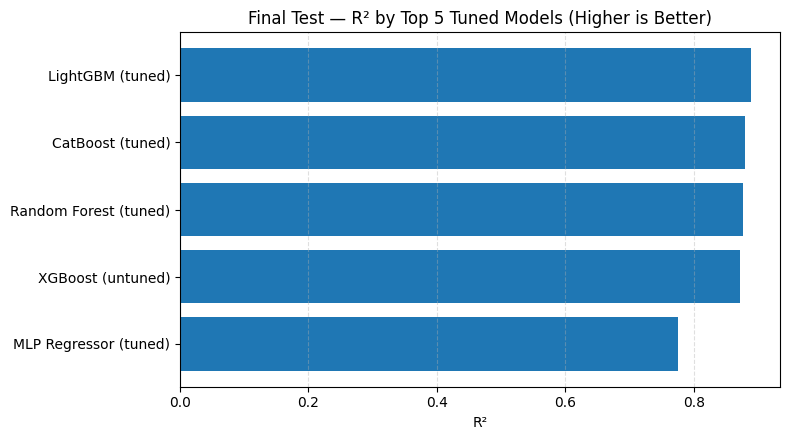

In [ ]:
import matplotlib.pyplot as plt

plot_df = final_test_df.sort_values("R²", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["Model"], plot_df["R²"])
plt.xlabel("R²")
plt.title("Final Test — R² by Top 5 Tuned Models (Higher is Better)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


LightGBM, CatBoost, Random Forest, and even untuned XGBoost deliver very similar high R², while MLP lags behind, suggesting this dataset’s price patterns are captured better by tree-based models than by the neural network.


### MAE Comparison Chart (Top 5)


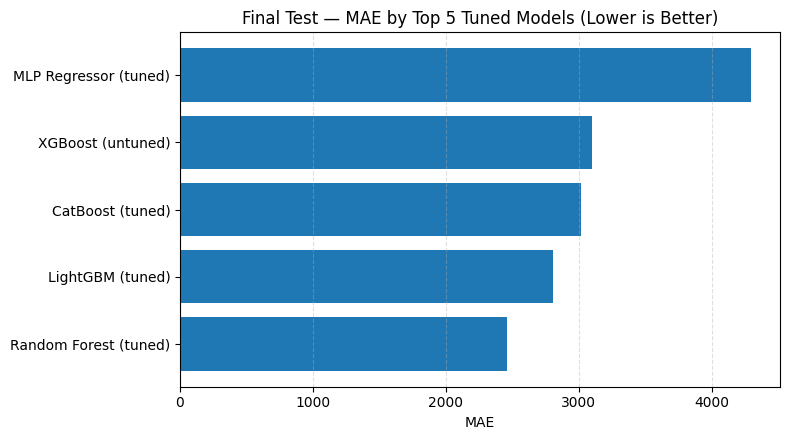

In [ ]:
plot_df = final_test_df.sort_values("MAE", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["Model"], plot_df["MAE"])
plt.xlabel("MAE")
plt.title("Final Test — MAE by Top 5 Tuned Models (Lower is Better)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Random Forest has the lowest MAE, with LightGBM next, while MLP shows the largest typical error, reinforcing that tree models handle the real-world price variation in this dataset more reliably.


### RMSE Comparison Chart (Top 5)


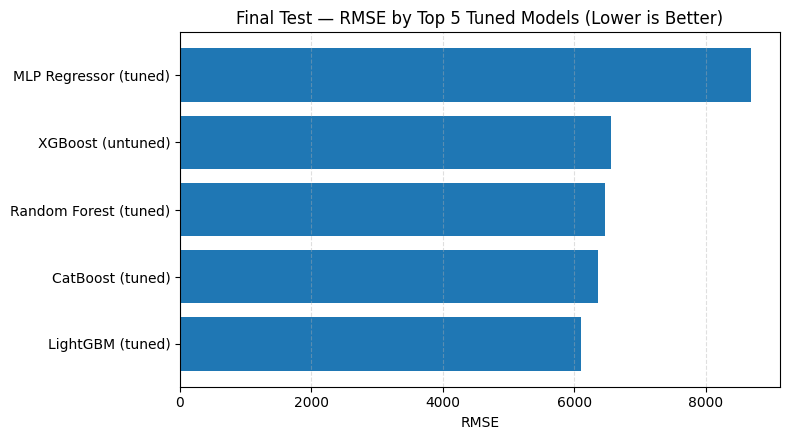

In [ ]:
plot_df = final_test_df.sort_values("RMSE", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["Model"], plot_df["RMSE"])
plt.xlabel("RMSE")
plt.title("Final Test — RMSE by Top 5 Tuned Models (Lower is Better)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


This likely reflects that boosted tree models handle non-linear price drivers and reduce large-error cases better in our used car data, whereas the lightly trained MLP struggles more with high-priced outliers that RMSE penalizes strongly.


### Trade-off Visualization - R² vs MAE

This scatter helps summarize the performance trade-off between accuracy (R²) and error (MAE).


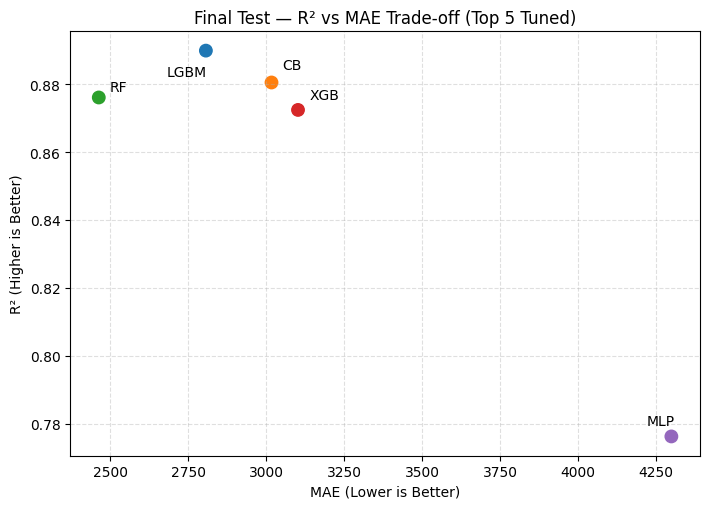

In [ ]:
label_map = {
    "Random Forest (tuned)": "RF",
    "CatBoost (tuned)": "CB",
    "LightGBM (tuned)": "LGBM",
    "XGBoost (untuned)": "XGB",
    "MLP Regressor (tuned)": "MLP"
}

plot_df = final_test_df.copy()
plot_df["Short"] = plot_df["Model"].map(label_map).fillna(plot_df["Model"])

plt.figure(figsize=(7.2, 5.2))

short_labels = plot_df["Short"].tolist()
unique_labels = list(dict.fromkeys(short_labels))
cmap = plt.cm.tab10
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}
colors = plot_df["Short"].map(color_map)

plt.scatter(plot_df["MAE"], plot_df["R²"], s=80, c=colors)

offsets = {
    "RF": (8, 5),
    "CB": (8, 10),
    "LGBM": (-28, -18),
    "XGB": (8, 8),
    "MLP": (-18, 8)
}

for _, row in plot_df.iterrows():
    dx, dy = offsets.get(row["Short"], (8, 8))
    plt.annotate(
        row["Short"],
        (row["MAE"], row["R²"]),
        textcoords="offset points",
        xytext=(dx, dy),
        ha="left",
        fontsize=10
    )

plt.xlabel("MAE (Lower is Better)")
plt.ylabel("R² (Higher is Better)")
plt.title("Final Test — R² vs MAE Trade-off (Top 5 Tuned)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


The trade-off plot shows LightGBM and Random Forest closest to the ideal corner (high R², low MAE), with CatBoost and XGBoost slightly higher MAE for similar R², while MLP sits clearly worse on both axes; this suggests that for our used car price data, tree ensembles capture the key non-linear signals with lower typical dollar error, making LightGBM and Random Forest the most balanced options for final price prediction.


### Actual vs Predicted (Top 5)

We plot a readable sample of 5,000 points per model to visualize prediction quality.


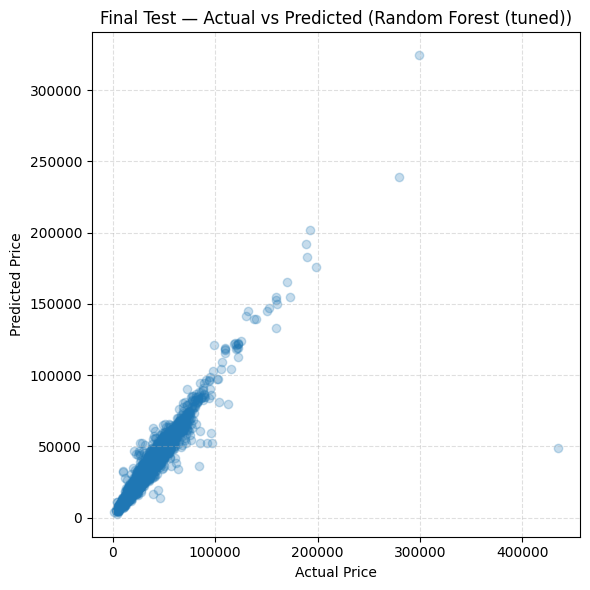

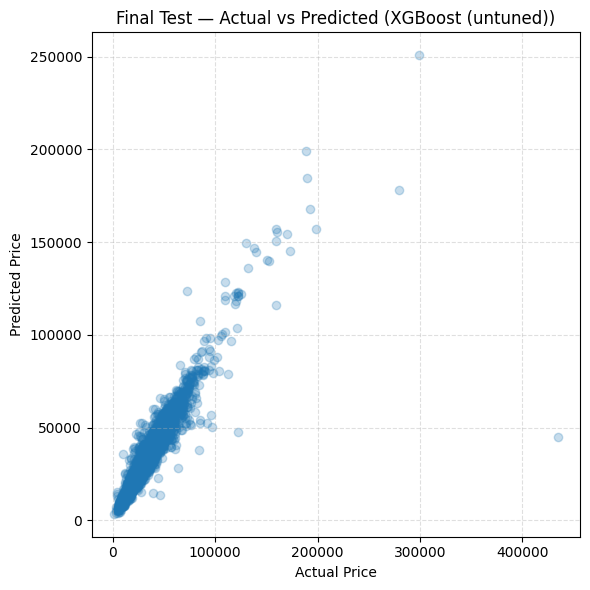

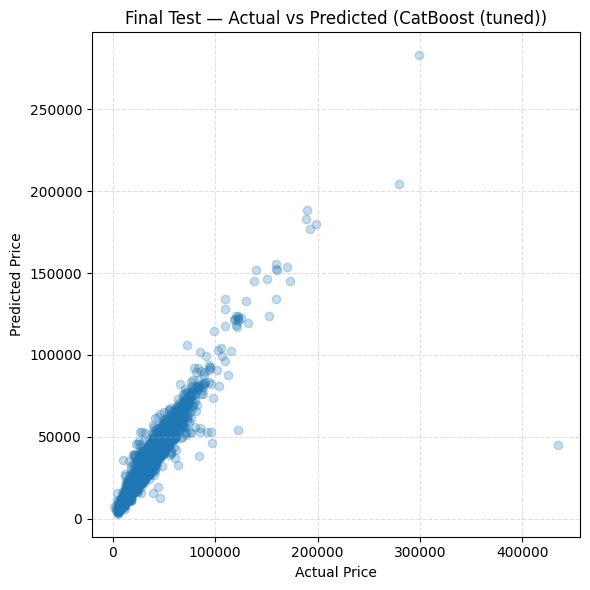

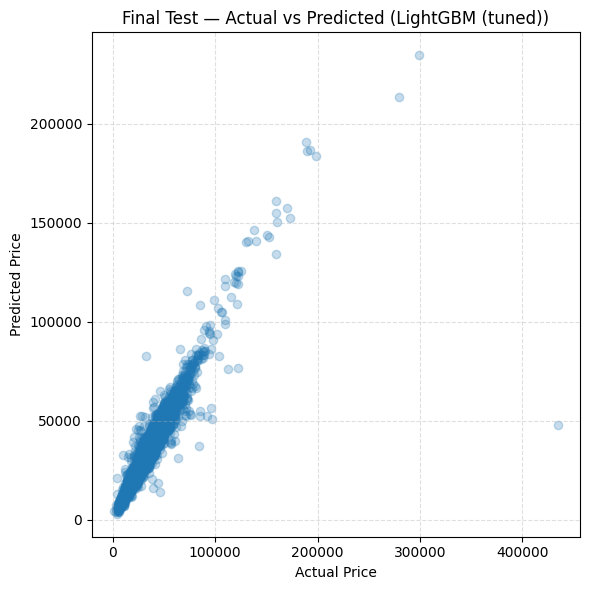

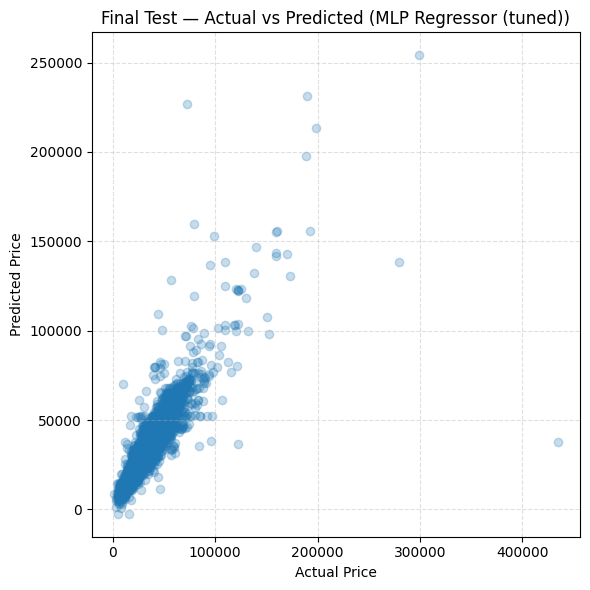

In [ ]:
sample_n = 5000

for name, preds in final_test_preds.items():
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test.iloc[:sample_n], preds[:sample_n], alpha=0.25)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Final Test — Actual vs Predicted ({name})")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


All five models follow the diagonal well for most cars in the common price range, but the tree-based models (Random Forest, XGBoost, CatBoost, LightGBM) show tighter clustering and fewer large deviations than MLP, while all models still struggle with rare very high-priced outliers; overall this supports the earlier metric results that tree ensembles capture the main non-linear price patterns in our used car data more reliably than the lightly trained neural network.


### Residual Distributions (Top 5)

Residuals help confirm whether errors are centered and reasonably narrow.


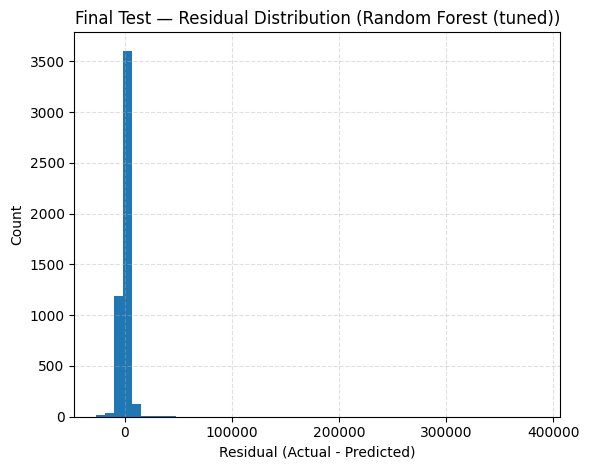

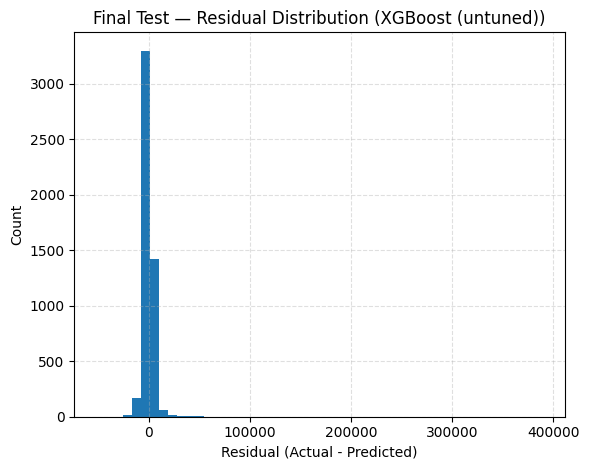

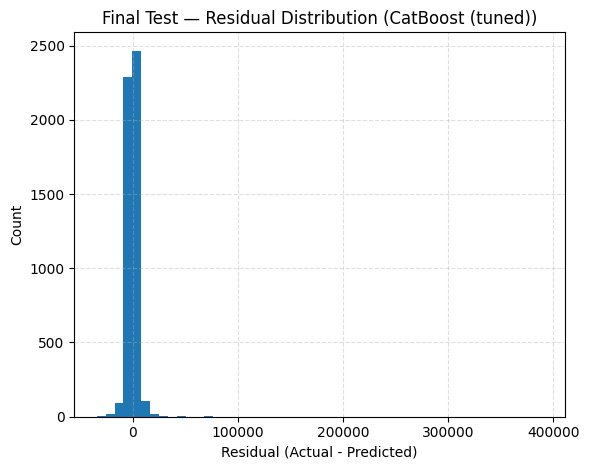

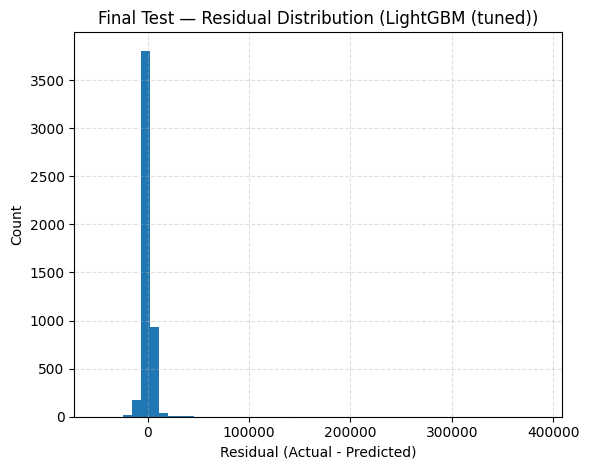

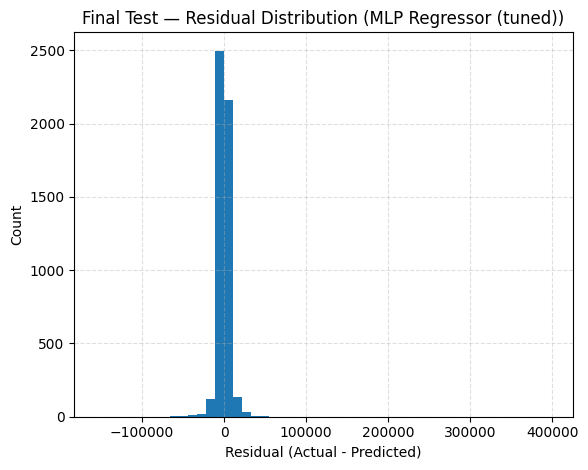

In [ ]:
sample_n = 5000

for name, preds in final_test_preds.items():
    residuals = y_test.iloc[:sample_n].values - preds[:sample_n]

    plt.figure(figsize=(6, 4.8))
    plt.hist(residuals, bins=50)
    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Count")
    plt.title(f"Final Test — Residual Distribution ({name})")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


The residuals for the four tree-based models are tightly centered around zero with relatively narrow spread, suggesting stable and unbiased predictions for most cars, while the MLP residuals appear wider and less concentrated, aligning with its higher MAE/RMSE; across all models, a small tail of large errors remains, likely driven by rare high-priced or unusual listings that are harder to predict from the available features.

### Feature Importance - Tree Models (Top 5)

We extract and visualize the top 15 features from each tuned tree model:
- Random Forest  
- XGBoost  
- LightGBM  
- CatBoost  


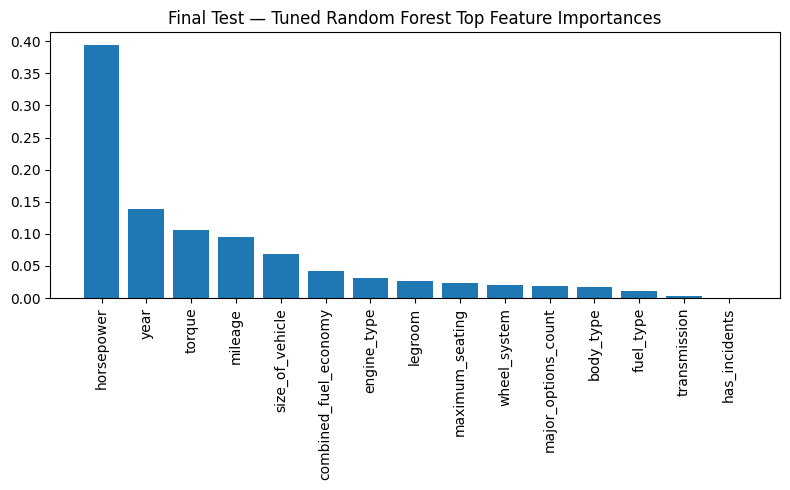

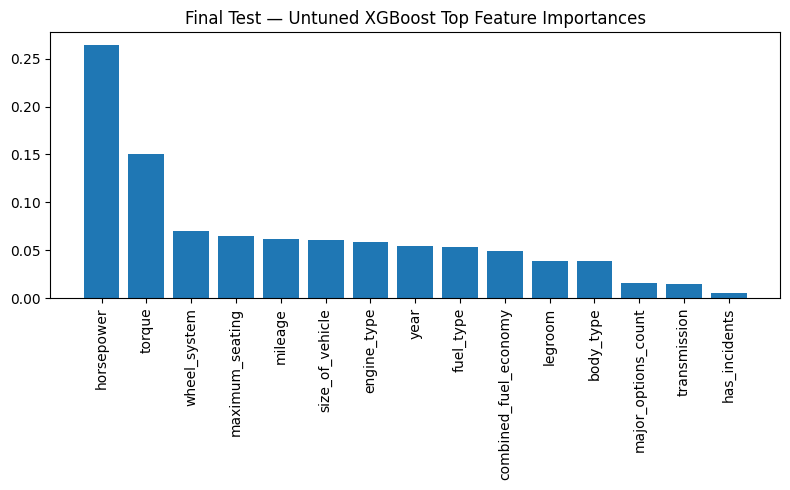

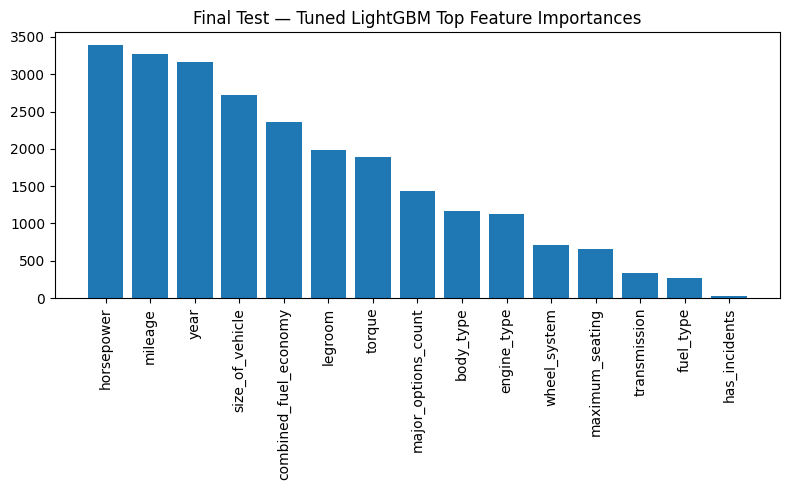

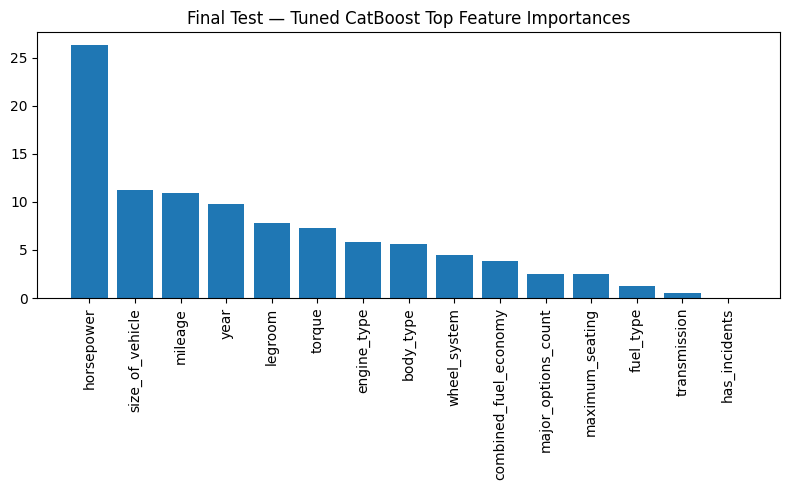

In [ ]:
top_n = 15

# Random Forest
rf_imp = (
    pd.Series(rf_tuned.feature_importances_, index=features)
    .sort_values(ascending=False)
    .head(top_n)
)
plt.figure(figsize=(8, 5))
plt.bar(rf_imp.index, rf_imp.values)
plt.xticks(rotation=90)
plt.title("Final Test — Tuned Random Forest Top Feature Importances")
plt.tight_layout()
plt.show()


# XGBoost
xgb_imp = (
    pd.Series(xgb.feature_importances_, index=features)
    .sort_values(ascending=False)
    .head(top_n)
)
plt.figure(figsize=(8, 5))
plt.bar(xgb_imp.index, xgb_imp.values)
plt.xticks(rotation=90)
plt.title("Final Test — Untuned XGBoost Top Feature Importances")
plt.tight_layout()
plt.show()


# LightGBM
lgbm_imp = (
    pd.Series(lgbm_tuned.feature_importances_, index=features)
    .sort_values(ascending=False)
    .head(top_n)
)
plt.figure(figsize=(8, 5))
plt.bar(lgbm_imp.index, lgbm_imp.values)
plt.xticks(rotation=90)
plt.title("Final Test — Tuned LightGBM Top Feature Importances")
plt.tight_layout()
plt.show()


# CatBoost
cb_imp_vals = cb_tuned.get_feature_importance()
cb_imp = (
    pd.Series(cb_imp_vals, index=features)
    .sort_values(ascending=False)
    .head(top_n)
)
plt.figure(figsize=(8, 5))
plt.bar(cb_imp.index, cb_imp.values)
plt.xticks(rotation=90)
plt.title("Final Test — Tuned CatBoost Top Feature Importances")
plt.tight_layout()
plt.show()


Across models, the same top drivers keep showing up: horsepower, year, mileage, torque.

- Random Forest: strongest focus on horsepower, then year and mileage.

- XGBoost: horsepower and torque lead, with some added impact from wheel system and seating.

- LightGBM: similar pattern, mixing power, age, and usage.

- CatBoost: highlights size_of_vehicle a bit more alongside horsepower and mileage.

Overall, Price is mainly explained by performance, age, and usage, with vehicle size and drivetrain adding smaller effects.

### Feature Importance - MLP (Permutation Importance)

Neural networks do not have built-in importance like tree models,
so we estimate importance using permutation importance on the test set.


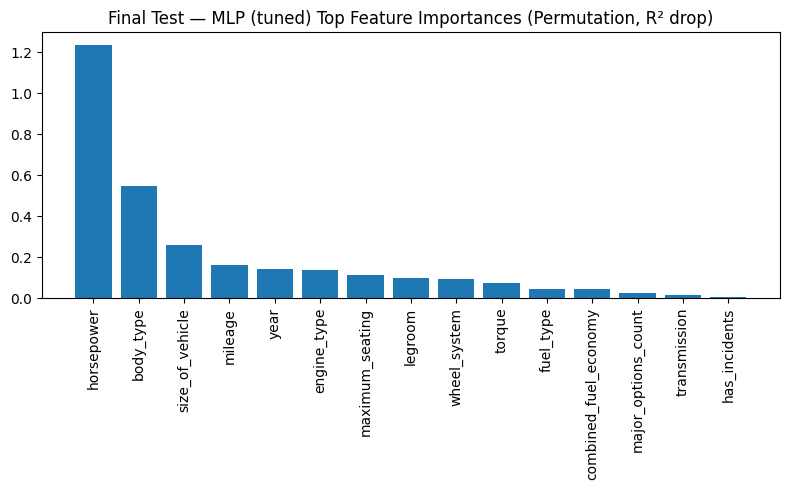

horsepower               1.234922
body_type                0.548701
size_of_vehicle          0.261048
mileage                  0.162151
year                     0.139891
engine_type              0.138871
maximum_seating          0.114583
legroom                  0.095716
wheel_system             0.094630
torque                   0.073024
fuel_type                0.044091
combined_fuel_economy    0.041792
major_options_count      0.022138
transmission             0.013682
has_incidents            0.005894
dtype: float64

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    mlp_tuned,
    X_test_scaled,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

mlp_imp = (
    pd.Series(perm.importances_mean, index=features)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(mlp_imp.head(top_n).index, mlp_imp.head(top_n).values)
plt.xticks(rotation=90)
plt.title("Final Test — MLP (tuned) Top Feature Importances (Permutation, R² drop)")
plt.tight_layout()
plt.show()

mlp_imp.head(20)


- MLP also ranks horsepower as the biggest driver.

- Body_type and size_of_vehicle matter more here than in some tree models.

- Mileage and year are still key, but slightly lower than the power/size signals.

- Seating, legroom, wheel_system add smaller improvements.

- Incidents and transmission have limited impact in this setup.

Overall, the MLP mainly learns price from power plus vehicle category/size, then adjusts with age and mileage.

## Phase 4 Conclusion

This phase was basically a race to see who can understand real-world used car pricing best. The linear models gave us a clean baseline, but they clearly struggled with the messy, non-linear nature of the market. Once we moved to tree-based models, the jump was obvious and consistent.

LightGBM (tuned) came out as the most reliable top performer, with CatBoost and Random Forest close behind, and interestingly XGBoost was strong even without tuning. The deep learning models didn’t beat the best tree methods here, which makes sense for structured tabular data like this. Across the top models, the story stays the same: horsepower, year, mileage, torque, and vehicle size are the strongest price signals.

So the main takeaway is simple: our Phase 3 features are strong, and the price patterns in this dataset are better captured by smart tree-based models than by linear assumptions. In the next phase, we’ll judge these finalists more carefully and decide which model is the best candidate for real use.